In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import nest_asyncio

# Apply nest_asyncio to allow multiple event loops in Jupyter/Colab
nest_asyncio.apply()

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [5]:
data = pd.read_csv("pd_EEG_features.csv")
data.head()

,id,gender,PPE,EEG,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1


In [6]:
del data['id']

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Columns: 754 entries, gender to class
dtypes: float64(749), int64(5)
memory usage: 4.3 MB


In [8]:
data = data.dropna()

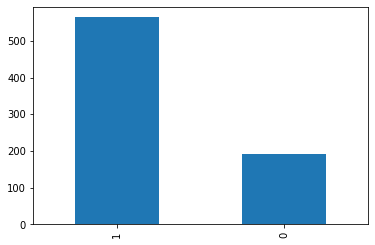

In [9]:
data['class'].value_counts().plot(kind='bar');

In [10]:
from sklearn.metrics import accuracy_score, classification_report

In [40]:
X = data.drop(["class"],axis =1)
y = data["class"]

In [41]:
from sklearn.feature_selection import SelectKBest, SelectPercentile, mutual_info_classif

selector = SelectPercentile(mutual_info_classif, percentile=1.5)
X_reduced = selector.fit_transform(X, y)
X_reduced.shape

(756, 12)

In [42]:
cols = selector.get_support(indices=True)
selected_columns = X.iloc[:,cols].columns.tolist()
selected_columns

['mean_MFCC_2nd_coef',
 'std_delta_delta_log_energy',
 'std_8th_delta_delta',
 'tqwt_energy_dec_27',
 'tqwt_entropy_shannon_dec_35',
 'tqwt_entropy_log_dec_11',
 'tqwt_entropy_log_dec_35',
 'tqwt_TKEO_mean_dec_12',
 'tqwt_TKEO_mean_dec_16',
 'tqwt_TKEO_std_dec_12',
 'tqwt_stdValue_dec_12',
 'tqwt_maxValue_dec_12']

In [43]:
df = data[['gender','mean_MFCC_2nd_coef',
 'std_delta_delta_log_energy',
 'std_8th_delta_delta',
 'tqwt_entropy_shannon_dec_35',
 'tqwt_entropy_log_dec_11',
 'tqwt_entropy_log_dec_35',
 'tqwt_TKEO_mean_dec_12',
 'tqwt_TKEO_mean_dec_16',
 'tqwt_TKEO_std_dec_12',
 'tqwt_stdValue_dec_12',
 'tqwt_stdValue_dec_15',
 'tqwt_maxValue_dec_12','class']]
df.to_csv('processed.csv')

In [44]:
df.head()

,gender,mean_MFCC_2nd_coef,std_delta_delta_log_energy,std_8th_delta_delta,tqwt_entropy_shannon_dec_35,tqwt_entropy_log_dec_11,tqwt_entropy_log_dec_35,tqwt_TKEO_mean_dec_12,tqwt_TKEO_mean_dec_16,tqwt_TKEO_std_dec_12,tqwt_stdValue_dec_12,tqwt_stdValue_dec_15,tqwt_maxValue_dec_12,class
0,1,2.4874,0.016392,0.012829,0.015562,-229943.2967,-3190.1752,0.000023,0.008643,0.000059,0.004324,0.063087,0.024286,1
1,1,2.8986,0.014222,0.010645,0.023860,-230526.8175,-3106.4317,0.000024,0.007183,0.000169,0.004344,0.055913,0.099695,1
2,1,3.2208,0.039709,0.016553,0.020677,-246592.6024,-3082.5691,0.000009,0.003969,0.000021,0.002657,0.041144,0.026241,1
3,0,3.1023,0.015560,0.015533,1.737700,-255107.4287,-1965.3808,0.000162,0.069072,0.000493,0.016104,0.158720,0.122970,1
4,0,2.9451,0.011037,0.014382,1.028700,-252647.9964,-2102.3852,0.000147,0.070589,0.000328,0.015422,0.169000,0.102950,1


In [45]:
df.columns

Index(['gender', 'mean_MFCC_2nd_coef', 'std_delta_delta_log_energy',
       'std_8th_delta_delta', 'tqwt_entropy_shannon_dec_35',
       'tqwt_entropy_log_dec_11', 'tqwt_entropy_log_dec_35',
       'tqwt_TKEO_mean_dec_12', 'tqwt_TKEO_mean_dec_16',
       'tqwt_TKEO_std_dec_12', 'tqwt_stdValue_dec_12', 'tqwt_stdValue_dec_15',
       'tqwt_maxValue_dec_12', 'class'],
      dtype='object')

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 756 entries, 0 to 755
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       756 non-null    int64  
 1   mean_MFCC_2nd_coef           756 non-null    float64
 2   std_delta_delta_log_energy   756 non-null    float64
 3   std_8th_delta_delta          756 non-null    float64
 4   tqwt_entropy_shannon_dec_35  756 non-null    float64
 5   tqwt_entropy_log_dec_11      756 non-null    float64
 6   tqwt_entropy_log_dec_35      756 non-null    float64
 7   tqwt_TKEO_mean_dec_12        756 non-null    float64
 8   tqwt_TKEO_mean_dec_16        756 non-null    float64
 9   tqwt_TKEO_std_dec_12         756 non-null    float64
 10  tqwt_stdValue_dec_12         756 non-null    float64
 11  tqwt_stdValue_dec_15         756 non-null    float64
 12  tqwt_maxValue_dec_12         756 non-null    float64
 13  class               

In [46]:
X = df.drop(columns=['class']).values  # Replace 'target' with the actual target column name
y = df['class'].values

In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [48]:
print(X_scaled.shape, y.shape)

(756, 13) (756,)


In [49]:
# Convert the feature data to float32 and label data to int64
X_scaled = X_scaled.astype(np.float32)
y = y.astype(np.int64)

# Check the data types to confirm
print(f"Features type: {X_scaled.dtype}, Labels type: {y.dtype}")


Features type: float32, Labels type: int64


In [50]:
# Create a function to generate federated data
def create_federated_data(X, y, num_clients):
    client_data = []
    client_data_size = len(X) // num_clients
    for i in range(num_clients):
        start = i * client_data_size
        end = (i + 1) * client_data_size
        client_data.append(tf.data.Dataset.from_tensor_slices((X[start:end], y[start:end])).batch(32))
    return client_data

In [51]:
# Create federated data (split data into 10 clients)
num_clients = 10
federated_train_data = create_federated_data(X_scaled, y, num_clients)


In [52]:
# Check the first client’s data
for example in federated_train_data[0].take(1):
    print(example)

(<tf.Tensor: shape=(32, 13), dtype=float32, numpy=
array([[ 9.68742251e-01,  7.35176861e-01,  2.72961348e-01,
        -1.07046914e+00, -3.62377375e-01, -3.89473945e-01,
        -7.00275004e-01, -3.15745175e-01, -6.04946911e-01,
        -4.27830130e-01, -7.00344145e-01, -6.26697481e-01,
        -9.26451087e-01],
       [ 9.68742251e-01,  9.82245922e-01,  3.79271172e-02,
        -1.49683368e+00, -3.60427320e-01, -4.02459174e-01,
        -5.85908592e-01, -3.15594435e-01, -6.20523453e-01,
        -4.00936007e-01, -6.99656129e-01, -7.05231369e-01,
        -1.37285680e-01],
       [ 9.68742251e-01,  1.17583942e+00,  2.79844213e+00,
        -3.43463123e-01, -3.61175328e-01, -7.59975195e-01,
        -5.53320050e-01, -3.18443686e-01, -6.54832542e-01,
        -4.37091351e-01, -7.57404029e-01, -8.66907954e-01,
        -9.05991733e-01],
       [-1.03226638e+00,  1.10463881e+00,  1.82846844e-01,
        -5.42589366e-01,  4.23258804e-02, -9.49457765e-01,
         9.72395599e-01, -2.89515704e-01,  3.

# DNN with FL

In [53]:
import tensorflow as tf
import tensorflow_federated as tff

In [54]:
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(X_scaled.shape[1],)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')  # Parkinson's disease binary classification
    ])
    #model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [55]:
def model_fn():
    keras_model = create_model()
    return tff.learning.from_keras_model(
        keras_model,
        input_spec=(tf.TensorSpec(shape=[None, X_scaled.shape[1]], dtype=tf.float32),
                    tf.TensorSpec(shape=[None], dtype=tf.int64)),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[tf.keras.metrics.BinaryAccuracy()]
    )

In [56]:
client_optimizer_fn = lambda: tf.keras.optimizers.Adam(learning_rate=0.001)
server_optimizer_fn = lambda: tf.keras.optimizers.Adam(learning_rate=1.0)

In [57]:
# Build the federated averaging process
iterative_process = tff.learning.build_federated_averaging_process(
    model_fn,
    client_optimizer_fn=client_optimizer_fn,
    server_optimizer_fn=server_optimizer_fn
)

In [58]:
# Initialize the federated learning process
state = iterative_process.initialize()

In [60]:
num_rounds = 50
for round_num in range(1, num_rounds + 1):
    state, metrics = iterative_process.next(state, federated_train_data)
    print(f"Round {round_num}, Metrics: {metrics}")

Round 1, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306818), ('loss', 3.8026433)]))])
Round 2, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306818), ('loss', 3.8026435)]))])
Round 3, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306818), ('loss', 3.8026428)]))])
Round 4, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306818), ('loss', 3.8026435)]))])
Round 5, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())

Round 39, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306818), ('loss', 3.8026435)]))])
Round 40, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306818), ('loss', 3.8026435)]))])
Round 41, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306817), ('loss', 3.8026435)]))])
Round 42, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306817), ('loss', 3.8026438)]))])
Round 43, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process'

In [62]:
keras_model = create_model()
keras_model.save('tff_model.h5')

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.20, random_state = 42)

In [83]:
model = tf.keras.models.load_model('tff_model.h5')
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [84]:
loss, accuracy = model.evaluate(X_test, y_test)

# Print the evaluation results
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

5/5 [==============================] - 0s 805us/step - loss: 0.6819 - accuracy: 0.5789
Test Loss: 0.6819158792495728
Test Accuracy: 0.5789473652839661


In [142]:
val1 = 0.57

In [85]:
from sklearn.metrics import classification_report, confusion_matrix

# Get model predictions on the test set
y_pred = (model.predict(X_test) > 0.5).astype("int32")  # Convert probabilities to binary predictions

# Print classification report (Precision, Recall, F1-Score)
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{cm}")

              precision    recall  f1-score   support

           0       0.31      0.55      0.40        38
           1       0.80      0.59      0.68       114

    accuracy                           0.58       152
   macro avg       0.55      0.57      0.54       152
weighted avg       0.68      0.58      0.61       152

Confusion Matrix:
[[21 17]
 [47 67]]


# CNN with FL

In [91]:
import tensorflow as tf
from tensorflow.keras import layers, models

# CNN Model Definition
def create_cnn_model(input_shape):
    model = models.Sequential()

    # Add Convolutional and Pooling layers
    model.add(layers.Reshape(target_shape=(input_shape[0], 1), input_shape=input_shape))  # Reshape for CNN input
    model.add(layers.Conv1D(64, 3, activation='relu'))  # 1D convolution layer
    model.add(layers.MaxPooling1D(2))  # Max pooling layer

    model.add(layers.Conv1D(128, 3, activation='relu'))  # Another convolutional layer
    model.add(layers.MaxPooling1D(2))

    # Flatten the output from convolutional layers
    model.add(layers.Flatten())

    # Fully connected layer
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))  # Dropout for regularization

    # Output layer for binary classification
    model.add(layers.Dense(1, activation='sigmoid'))

    

    return model


In [92]:
def model_fn():
    keras_model = create_cnn_model(input_shape=(13,))
    return tff.learning.from_keras_model(
        keras_model,
        input_spec=(tf.TensorSpec(shape=[None, X_scaled.shape[1]], dtype=tf.float32),
                    tf.TensorSpec(shape=[None], dtype=tf.int64)),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[tf.keras.metrics.BinaryAccuracy()]
    )

In [93]:
# Build the federated averaging process
iterative_process = tff.learning.build_federated_averaging_process(
    model_fn,
    client_optimizer_fn=client_optimizer_fn,
    server_optimizer_fn=server_optimizer_fn
)

In [94]:
state = iterative_process.initialize()

In [95]:
num_rounds = 50
for round_num in range(1, num_rounds + 1):
    state, metrics = iterative_process.next(state, federated_train_data)
    print(f"Round {round_num}, Metrics: {metrics}")

Round 1, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.6158144), ('loss', 0.68129605)]))])
Round 2, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306818), ('loss', 3.8026433)]))])
Round 3, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306818), ('loss', 3.8026433)]))])
Round 4, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306818), ('loss', 3.8026433)]))])
Round 5, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ()

Round 39, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306817), ('loss', 3.8026433)]))])
Round 40, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306818), ('loss', 3.8026433)]))])
Round 41, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306817), ('loss', 3.8026435)]))])
Round 42, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process', ())])), ('train', OrderedDict([('binary_accuracy', 0.7306818), ('loss', 3.8026433)]))])
Round 43, Metrics: OrderedDict([('broadcast', ()), ('aggregation', OrderedDict([('value_sum_process', ()), ('weight_sum_process'

In [96]:
keras_model = create_cnn_model(input_shape=(13,))
keras_model.save('tff_cnn_model.h5')

In [97]:
model = tf.keras.models.load_model('tff_cnn_model.h5')
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [98]:
loss, accuracy = model.evaluate(X_test, y_test)

# Print the evaluation results
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

5/5 [==============================] - 0s 997us/step - loss: 0.6567 - accuracy: 0.7500
Test Loss: 0.6567240357398987
Test Accuracy: 0.75


In [143]:
val2 = 0.75

In [99]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")  # Convert probabilities to binary predictions

# Print classification report (Precision, Recall, F1-Score)
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{cm}")

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        38
           1       0.75      1.00      0.86       114

    accuracy                           0.75       152
   macro avg       0.38      0.50      0.43       152
weighted avg       0.56      0.75      0.64       152

Confusion Matrix:
[[  0  38]
 [  0 114]]


In [103]:
from tensorflow.keras.models import Model, load_model
model = load_model('tff_cnn_model.h5')
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [112]:
data = np.array([0,2.9311,0.015363,0.018959,1.4709,-252612.6532,-2114.5639,0.00018873,0.10106,0.00039114,0.018172,0.27556,0.083471
])

In [117]:
dj = data.reshape(-1,13,1)
prediction_proba = model.predict(dj)

In [118]:
predict=np.argmax(prediction_proba,axis=1)

In [119]:
predict

array([0], dtype=int64)

# DL without FL

In [120]:
df.columns

Index(['gender', 'mean_MFCC_2nd_coef', 'std_delta_delta_log_energy',
       'std_8th_delta_delta', 'tqwt_entropy_shannon_dec_35',
       'tqwt_entropy_log_dec_11', 'tqwt_entropy_log_dec_35',
       'tqwt_TKEO_mean_dec_12', 'tqwt_TKEO_mean_dec_16',
       'tqwt_TKEO_std_dec_12', 'tqwt_stdValue_dec_12', 'tqwt_stdValue_dec_15',
       'tqwt_maxValue_dec_12', 'class'],
      dtype='object')

In [121]:
X = df.drop(["class"],axis =1)
y = df["class"]

# CNN

In [123]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D


In [124]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [125]:
X_train=X_train.values
X_test=X_test.values

In [126]:
X_train = X_train.reshape(-1, X_train.shape[1],1)
X_test = X_test.reshape(-1, X_test.shape[1],1)

Y_train=to_categorical(y_train)
Y_test=to_categorical(y_test)

In [129]:
verbose, epoch, batch_size = 1, 100, 4
activationFunction='relu'

def CNN():
    
    cnnmodel = Sequential()
    cnnmodel.add(Conv1D(filters=128, kernel_size=2, activation='relu',input_shape=(X_train.shape[1],X_train.shape[2])))
    cnnmodel.add(MaxPooling1D(pool_size=2))
    cnnmodel.add(Dropout(rate=0.2))
    cnnmodel.add(Flatten())
    cnnmodel.add(Dense(2, activation='softmax'))
    cnnmodel.compile(optimizer='adam', loss='categorical_crossentropy',metrics=['accuracy'])
    cnnmodel.summary()
    return cnnmodel

cnnmodel = CNN()

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d_3 (Conv1D)            (None, 12, 128)           384       
_________________________________________________________________
max_pooling1d_3 (MaxPooling1 (None, 6, 128)            0         
_________________________________________________________________
dropout_2 (Dropout)          (None, 6, 128)            0         
_________________________________________________________________
flatten_2 (Flatten)          (None, 768)               0         
_________________________________________________________________
dense_9 (Dense)              (None, 2)                 1538      
Total params: 1,922
Trainable params: 1,922
Non-trainable params: 0
_________________________________________________________________


In [130]:
modelhistory= cnnmodel.fit(X_train, Y_train, epochs=50, verbose=verbose, validation_split=0.2, batch_size = batch_size)

Epoch 1/50
  1/121 [..............................] - ETA: 0s - loss: 3320.2498 - accuracy: 0.5000WARNING:tensorflow:Callbacks method `on_train_batch_end` is slow compared to the batch time (batch time: 0.0000s vs `on_train_batch_end` time: 0.0010s). Check your callbacks.


121/121 [==============================] - 0s 2ms/step - loss: 2768.0588 - accuracy: 0.6273 - val_loss: 632.9136 - val_accuracy: 0.7934
Epoch 2/50
121/121 [==============================] - 0s 849us/step - loss: 2275.5767 - accuracy: 0.6046 - val_loss: 39.1084 - val_accuracy: 0.7934
Epoch 3/50
121/121 [==============================] - 0s 849us/step - loss: 2033.7721 - accuracy: 0.6170 - val_loss: 403.2770 - val_accuracy: 0.7934
Epoch 4/50
121/121 [==============================] - 0s 857us/step - loss: 1458.0804 - accuracy: 0.6211 - val_loss: 649.1080 - val_accuracy: 0.7934
Epoch 5/50
121/121 [==============================] - 0s 849us/step - loss: 1137.2750 - accuracy: 0.6377 - val_loss: 498.4076 - val_accuracy: 0.7934
Epoch 6/50
121/121 [==============================] - 0s 841us/step - loss: 754.6341 - accuracy: 0.6398 - val_loss: 853.8241 - val_accuracy: 0.7934
Epoch 7/50
121/121 [==============================] - 0s 866us/step - loss: 623.2328 - accuracy: 0.6025 - val_loss: 315.3

In [144]:
val3 = modelhistory.history['val_accuracy'][49]

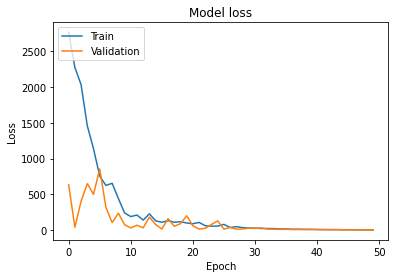

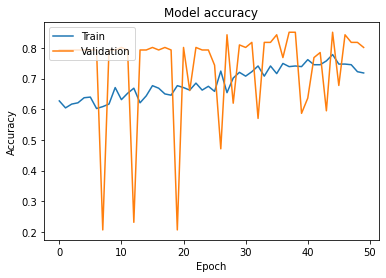

In [131]:
# Plot training & validation loss values
plt.plot(modelhistory.history['loss'])
plt.plot(modelhistory.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('loss.png', format='png', dpi=1200)
plt.show()


# Plot training & validation accuracy values
plt.plot(modelhistory.history['accuracy'])
plt.plot(modelhistory.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('accuracy.png', format='png', dpi=1200)
plt.show()

# ML

In [132]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((604, 13), (604,), (152, 13), (152,))

# XGBoost

In [145]:
from xgboost import XGBClassifier

# instantiate the model 
clf = XGBClassifier()

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

val4 = accuracy_score(y_pred, y_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.61      0.82      0.70        28
           1       0.96      0.88      0.92       124

    accuracy                           0.87       152
   macro avg       0.78      0.85      0.81       152
weighted avg       0.89      0.87      0.88       152



# Random Forest

In [146]:
from sklearn.ensemble import RandomForestClassifier

# instantiate the model 
clf = RandomForestClassifier()

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

val5 = accuracy_score(y_pred, y_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.61      0.85      0.71        27
           1       0.96      0.88      0.92       125

    accuracy                           0.88       152
   macro avg       0.79      0.87      0.81       152
weighted avg       0.90      0.88      0.88       152



# Decision Tree

In [147]:
from sklearn.tree import DecisionTreeClassifier

# instantiate the model 
clf = DecisionTreeClassifier()

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

val6 = accuracy_score(y_pred, y_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.63      0.67      0.65        36
           1       0.89      0.88      0.89       116

    accuracy                           0.83       152
   macro avg       0.76      0.77      0.77       152
weighted avg       0.83      0.83      0.83       152



# Extension

In [148]:
from sklearn.ensemble import VotingClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

bdt = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), algorithm="SAMME", n_estimators=200
)

model = VotingClassifier(estimators= [('BoostDT', bdt),('RF', rf)], voting='soft')

model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [149]:
print(classification_report(predictions, y_test))

              precision    recall  f1-score   support

           0       0.63      0.89      0.74        27
           1       0.97      0.89      0.93       125

    accuracy                           0.89       152
   macro avg       0.80      0.89      0.83       152
weighted avg       0.91      0.89      0.90       152



In [150]:
val7 = accuracy_score(predictions, y_test)

# Comparison

In [151]:
results=pd.DataFrame({'Model':['DNN-FL','CNN-FL','CNN','XGB','RF','DT','Extension'],
                    'Accuracy Score':[val1,val2,val3,val4,val5,val6,val7]})
result_df=results.sort_values(by='Accuracy Score', ascending=False)
result_df=result_df.set_index('Model')
result_df

,Accuracy Score
Model,
Extension,0.888158
RF,0.875000
XGB,0.868421
DT,0.828947
CNN,0.801653
CNN-FL,0.750000
DNN-FL,0.570000


# Modelling

In [140]:
import joblib
#filename = 'model.sav'
joblib.dump(model, 'model.sav')

['model.sav']

# Graph

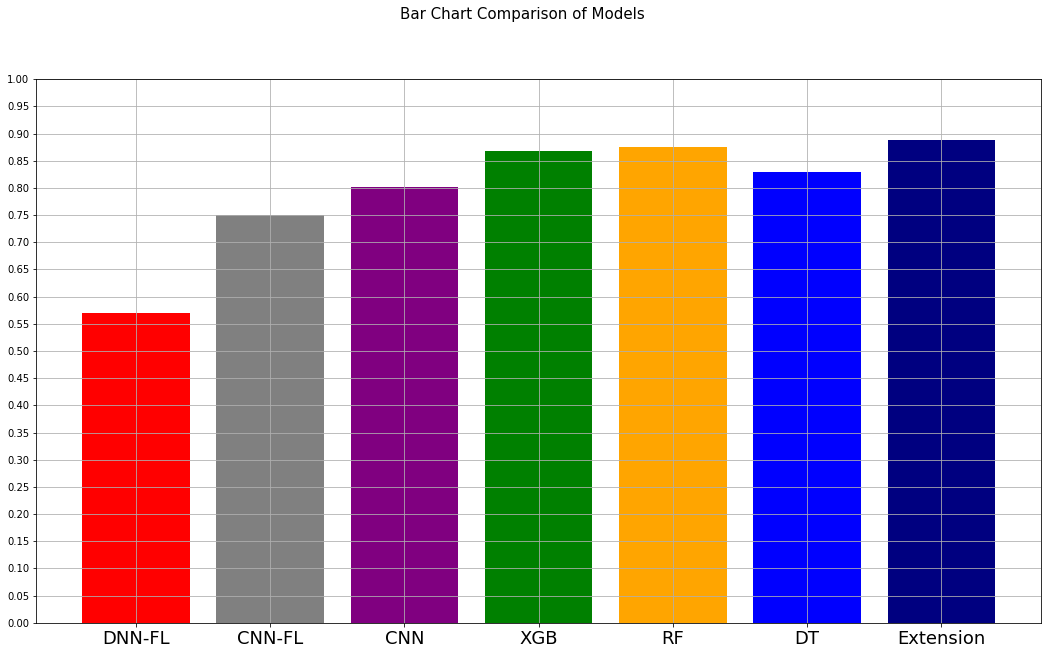

In [154]:
algorithms=('DNN-FL','CNN-FL','CNN','XGB','RF','DT','Extension')
scores = (val1,val2,val3,val4,val5,val6,val7)
y_pos = np.arange(1,8)
colors = ("red","gray","purple","green","orange","blue","navy")
plt.figure(figsize=(18,10))
plt.bar(y_pos,scores,color=colors)
plt.xticks(y_pos,algorithms,fontsize=18)
plt.yticks(np.arange(0.00, 1.01, step=0.05))
plt.grid()
plt.suptitle("Bar Chart Comparison of Models",fontsize=15)
plt.show()